In [1]:
import pandas as pd
import re

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
import gdown

file_url = "https://drive.google.com/uc?id=1tZ2eBa1g4fjdwG79WI8TLmqIz_LIe_im"
output_path = "/content/DLS_Measurements_20240531.xlsx"
gdown.download(file_url, output_path, quiet=False)

DLS_0531_file_path = "/content/DLS_Measurements_20240531.xlsx"

Downloading...
From: https://drive.google.com/uc?id=1tZ2eBa1g4fjdwG79WI8TLmqIz_LIe_im
To: /content/DLS_Measurements_20240531.xlsx
100%|██████████| 40.3k/40.3k [00:00<00:00, 50.8MB/s]


In [6]:
def parse_DLS_measurements(file_path):
  DLS_df = pd.read_excel(file_path)

  # Group the DataFrame by 'Radius (nm)' and calculate the mean of other columns
  DLS_df = DLS_df.groupby('Radius (nm)').mean()


  # Extract sample numbers and create separate dataframes
  sample_dataframes = {}
  for col in DLS_df.columns:
    if col != 'Radius (nm)':
      match = re.search(r'S(\d+)-(\d+)', col)
      if match:
        sample_num = int(match.group(1))
        if sample_num not in sample_dataframes:
          sample_dataframes[sample_num] = pd.DataFrame()
        sample_dataframes[sample_num][col] = DLS_df[col]

  # Now you have individual dataframes for each sample number
  # Access them like this:
  # sample_dataframes[1]  # for sample 1
  # sample_dataframes[2]  # for sample 2, etc.

  violin_plot_dict = {}
  for k in sample_dataframes.keys():
    s_df = sample_dataframes[k].fillna(0)
    if k in [1,2,3]:
      dict_i  = 0
    elif k in [4,5,6]:
      dict_i = 4
    elif k in [7,8]:
      dict_i = 6
    violin_plot_dict[dict_i] = np.dot(s_df.index, s_df)/100

  return sample_dataframes, violin_plot_dict

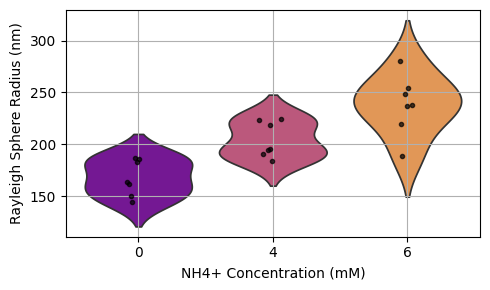

In [7]:
sample_dataframes, violin_plot_dict = parse_DLS_measurements(DLS_0531_file_path)
# Create the violin plot
plt.figure(figsize=(5,3))
palette = sns.color_palette("plasma", n_colors=3)
sns.set_palette(palette)
sns.violinplot(data=list(violin_plot_dict.values()), inner=None)  # Remove inner elements for cleaner plot

# Add jittered data points
for i, (k, v) in enumerate(violin_plot_dict.items()):
  x_vals = np.random.normal(i, 0.04, size=len(v)) # Add some jitter to x-coordinates
  plt.plot(x_vals, v, 'ko', markersize=3, alpha=0.7)

plt.xticks(range(len(violin_plot_dict)), [0,4,6]) # Setting xticks for better visibility
plt.xlabel("NH4+ Concentration (mM)")
plt.ylabel("Rayleigh Sphere Radius (nm)")
#plt.title("Violin Plot of Weighted Average Radius with Jittered Data Points")
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/violin_plot_0531.pdf')
plt.show()